In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("train.csv", sep=";")

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
df = df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin', 'Unnamed: 0', 'Embarked'], axis=1)


In [ ]:
# set age to only positive

df = df[df["Age"] >= 0]

#Encode the sex and age os they are numerical
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])


In [ ]:
df.head()

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # Controls both the randomness of the bootstrapping and feature sampling
)


In [ ]:
rf_clf.fit(X_train, y_train)

In [ ]:
y_pred = rf_clf.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
accuracy

In [1]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

NameError: name 'permutation_importance' is not defined

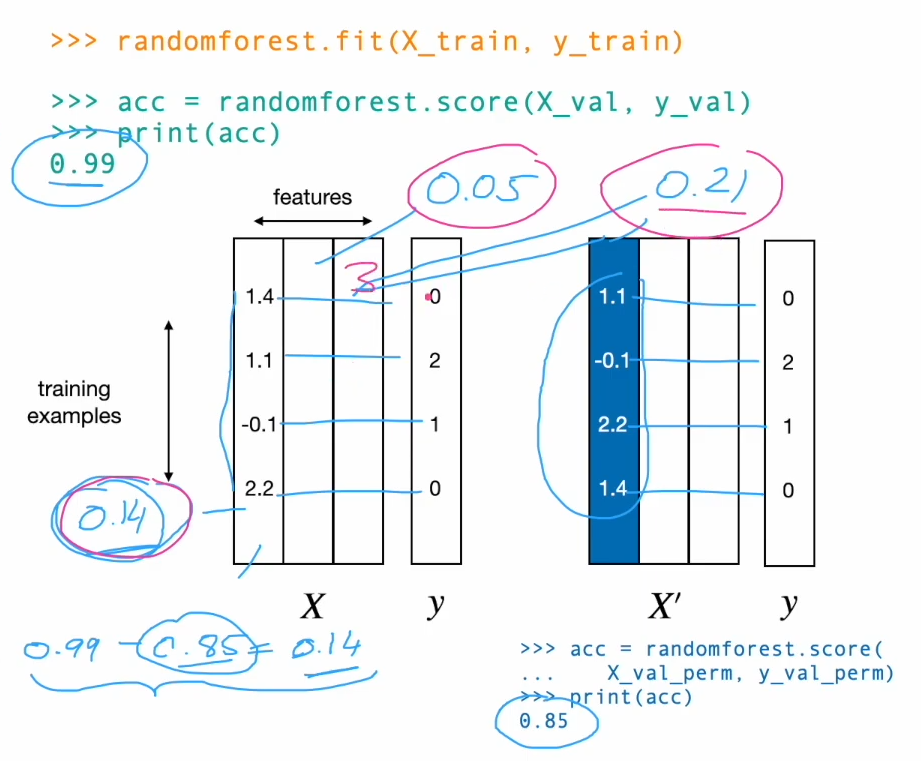

In [ ]:

# Ask question on if the feautre makes the person surive
# random forest means its not just one tree but multipale

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    rf_clf.estimators_[0],
    feature_names=X.columns,
    class_names=['Did not survive', 'Survived'],
    filled=True,
    max_depth=5
)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = rf_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did not survive', 'Survived'],
    yticklabels=['Did not survive', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

In [ ]:
person = pd.DataFrame({
'Pclass': [1],
'Sex': [0],
'Age':[23],
'SibSp': [2],
'Parch': [3],
'Fare': [100]
})

pred = rf_clf.predict_proba(person)[0]

In [ ]:
print(f"Did not survive: {pred[0] * 100:.2f}%")
print(f"Survived: {pred[1] * 100:.2f}%")